In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from sklearn.datasets import fetch_california_housing

In [4]:
boston = fetch_california_housing()

In [5]:
boston.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [6]:
print(boston.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
print(boston.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [8]:
print(boston.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


##Preparing The Datasets

In [9]:
dataset=pd.DataFrame(boston.data,columns=boston.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
dataset['price']=boston.target

In [11]:
dataset=pd.DataFrame(boston.data,columns=boston.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [13]:
##SUmarize the data
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [14]:
##Check missing values
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [15]:
##Exploratory Data Analysis
##Correlation
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


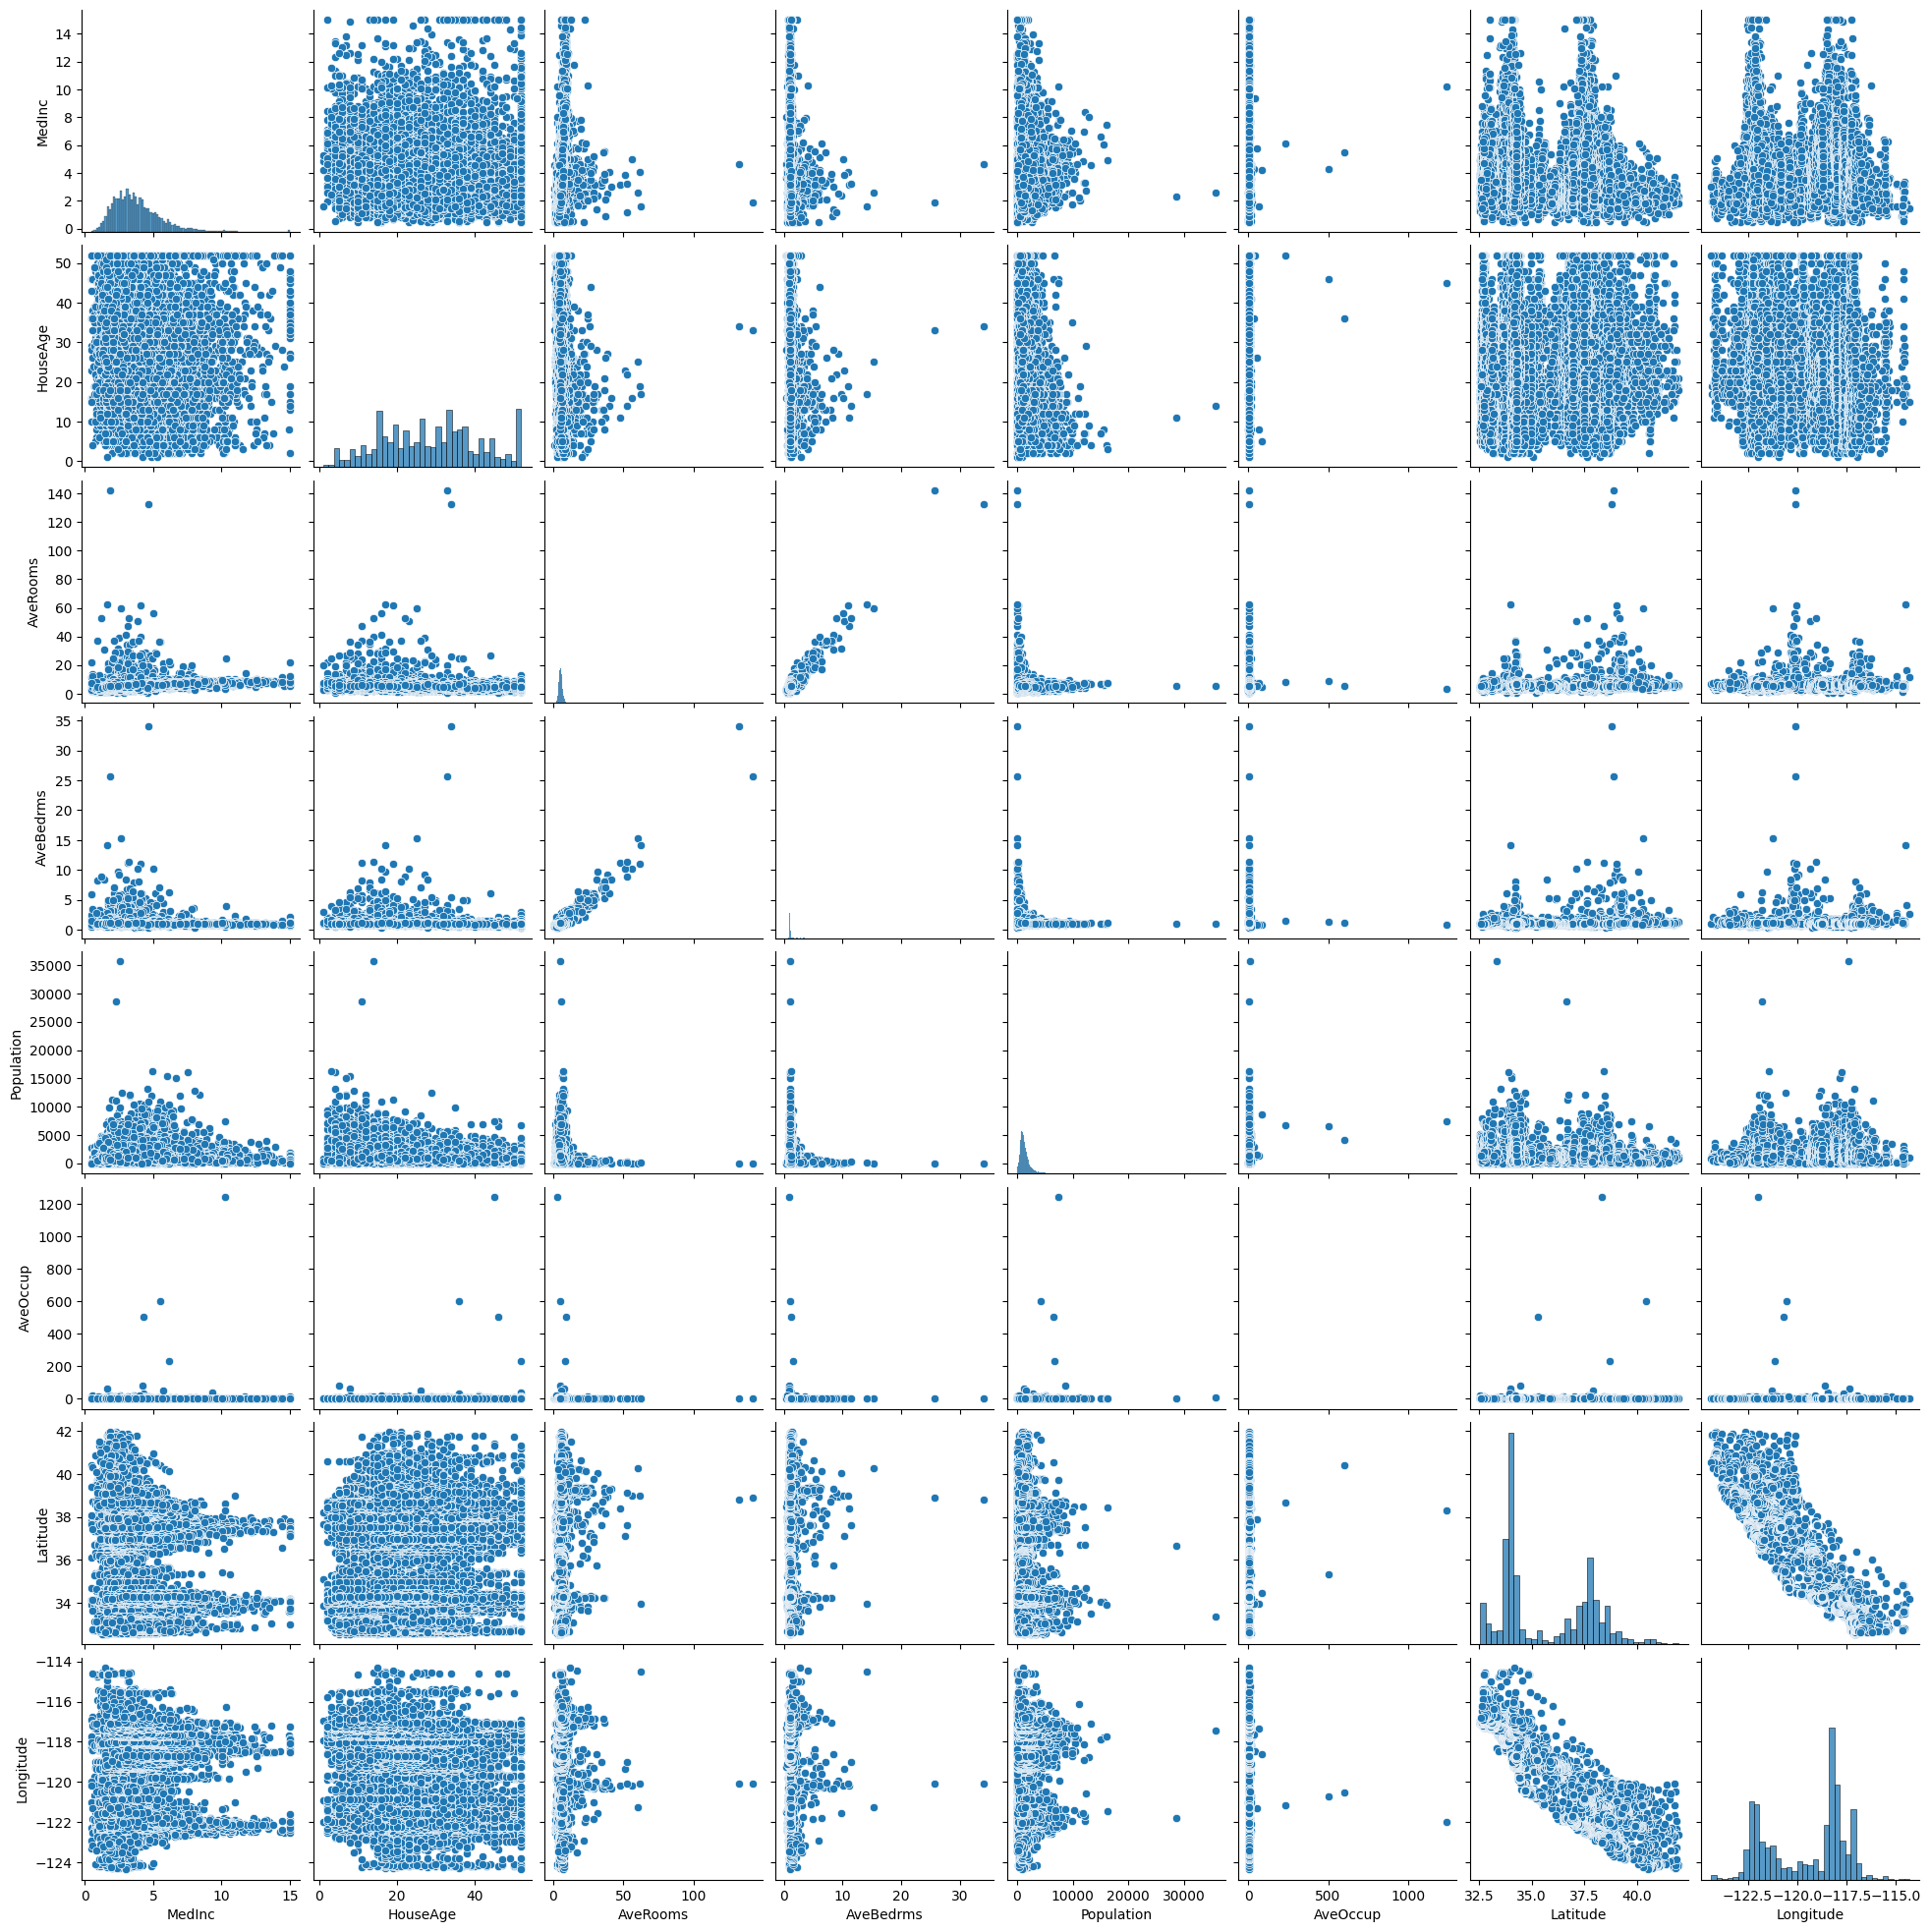

In [16]:
import seaborn as sns
sns.pairplot(dataset)

Text(0, 0.5, 'Average Bed Rooms')

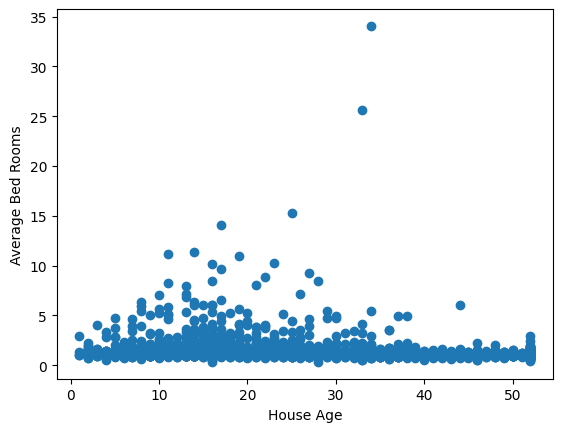

In [17]:
plt.scatter(dataset['HouseAge'],dataset['AveBedrms'])
plt.xlabel("House Age")
plt.ylabel("Average Bed Rooms")

Text(0, 0.5, 'Population')

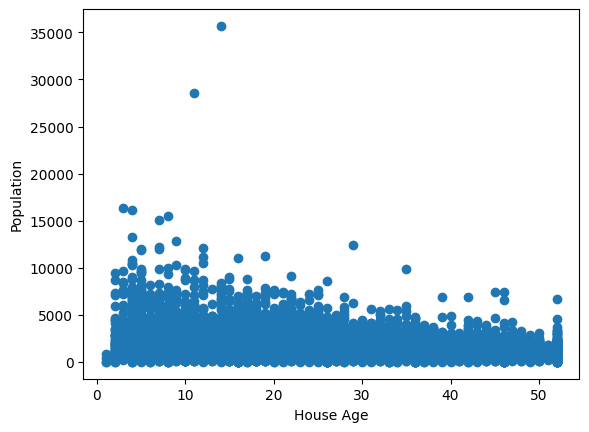

In [18]:
plt.scatter(dataset['HouseAge'],dataset['Population'])
plt.xlabel("House Age")
plt.ylabel("Population")

<Axes: xlabel='MedInc', ylabel='Latitude'>

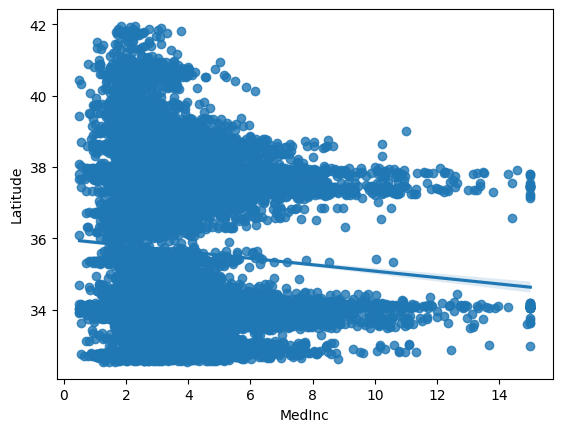

In [19]:
import seaborn as sns
sns.regplot(x="MedInc",y="Latitude",data=dataset)

In [20]:
## Indepedent and depedent features
x=dataset.iloc[:,1:]
y=dataset.iloc[:,0]


In [21]:
x.head()

,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [22]:
y

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: MedInc, Length: 20640, dtype: float64

In [23]:
##Train Test Split
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [24]:
x_train

,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...
11284,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [25]:
x_test

,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...
17505,47.0,4.195833,1.020833,581.0,2.420833,37.36,-121.90
13512,41.0,4.551852,1.118519,994.0,3.681481,34.11,-117.32
10842,16.0,3.762287,1.075614,5014.0,2.369565,33.67,-117.91
16559,10.0,5.502092,1.060371,5935.0,3.547519,37.82,-121.28


In [26]:
## Standardize the Dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [27]:
x_train=scaler.fit_transform(x_train)

In [28]:
x_test=scaler.transform(x_test)

In [58]:
import pickle
pickle.dump(scaler,open('scaling.pkl','wb'))

In [30]:
x_test

array([[-0.28346293, -0.50781822, -0.16927816, ...,  0.06127763,
         0.19166399,  0.28664112],
       [ 0.11294728, -0.16252032,  0.21332681, ..., -0.03551561,
        -0.23911452,  0.06196251],
       [ 1.85715216, -0.59546738,  0.19630786, ..., -0.14215427,
         1.00639726, -1.42590916],
       ...,
       [-0.99700129, -0.6830438 , -0.05009977, ..., -0.06058827,
        -0.92742367,  0.8358555 ],
       [-1.47269353,  0.02607207, -0.0841654 , ...,  0.03461374,
         1.01576201, -0.84673764],
       [-0.91771925, -0.84872893, -0.17506404, ..., -0.0407528 ,
        -0.70266966,  0.67109119]], shape=(6192, 7))

MODEL TRAINING

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
regression=LinearRegression()

In [33]:
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
## Print coefficient and  the Intercepts 
print(regression.coef_)

[-0.14528238  2.5748038  -2.19884482 -0.03357647  0.059239   -1.45328537
 -1.27809477]


In [35]:
print(regression.intercept_)

3.876891549003325


In [36]:
## on which Parameters the model is traiining 
regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [37]:
### Prediction with the Test Data 
reg_pred = regression.predict(x_test)

In [38]:
reg_pred

array([2.34254886, 3.23511901, 1.99713418, ..., 2.54351208, 3.81838909,
       2.29173637], shape=(6192,))

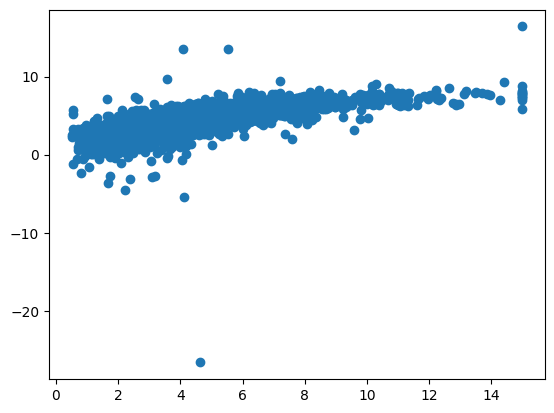

In [39]:
##Plot scatter plot 
plt.scatter(y_test,reg_pred)

In [40]:
## Residuals(Error)
residuals=y_test-reg_pred
residuals

20046   -0.661349
3024    -0.703819
15663    1.482966
20484    0.208845
9814    -1.336023
           ...   
17505   -0.122078
13512   -0.832990
10842    0.968488
16559   -0.168389
5786     0.760264
Name: MedInc, Length: 6192, dtype: float64

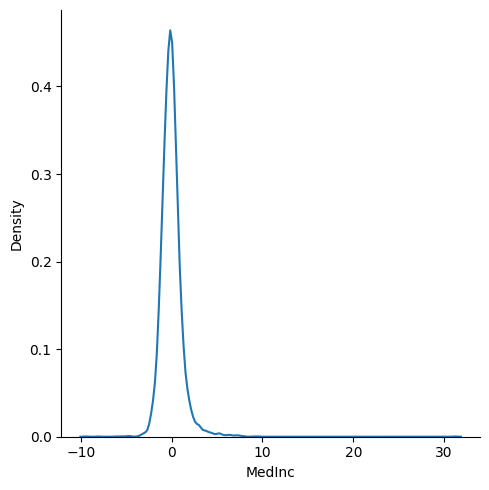

In [41]:
sns.displot(residuals,kind="kde")

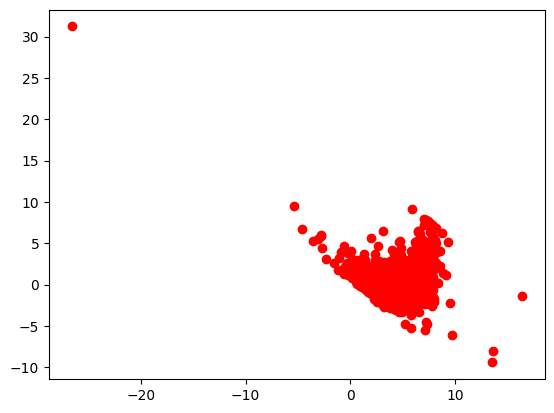

In [42]:
### Scatter plot Between Predictions And Residuals
## Uniform Distribution
plt.scatter(reg_pred,residuals,color="red")

In [43]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [44]:
print(mean_squared_error(y_test,reg_pred))
print(mean_absolute_error(y_test,reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))

1.465000922323099
0.7940990888375331
1.2103722246991209


## R square and adjusted R square

In [45]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
score

0.5889293660425962

In [46]:
## Adjusted R*2 = 1-[(1-r*2)*(n-1)/(n-k-1)]

#n:number of observations k: the number of Predictions of variables 


In [47]:
AdjustedR2=1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
AdjustedR2

0.588464053229255

In [48]:
boston.data[0].reshape(1,-1).shape


(1, 8)

In [49]:
## transform of new data
scaler.transform(boston.data[0].reshape(1,-1))

c:\Users\Ashwin Balvan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 8 features, but StandardScaler is expecting 7 features as input.

In [ ]:
scaler.transform(boston.data[0].reshape(1,-1))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 8 features, but StandardScaler is expecting 7 features as input.

In [54]:

import pandas as pd

new_data = pd.DataFrame(
    [[8.3252, 41, 6.984, 322, 2.555, 37.88, -122.23]]
)

scaled_data = scaler.transform(new_data)

c:\Users\Ashwin Balvan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [55]:

prediction = regression.predict(scaled_data)

print(prediction)

[12.70922091]


In [56]:
boston.data[0].reshape(1,-1).shape


(1, 8)

In [50]:
import pickle

In [51]:
pickle.dump(regression,open('regmodel.pkl','wb'))

In [52]:
pickled_model=pickle.load(open('regmodel.pkl','rb'))

In [57]:
pickled_model.predict(new_data)

array([183.38841798])